<a href="https://colab.research.google.com/github/FayezaQareen-TW/PRODIGY_DS_03/blob/main/PRODIGY_DS_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  
y
no     39922
yes     5289
Name: count, dtype: int64
Cleaned shape: (45211, 52)
Training si

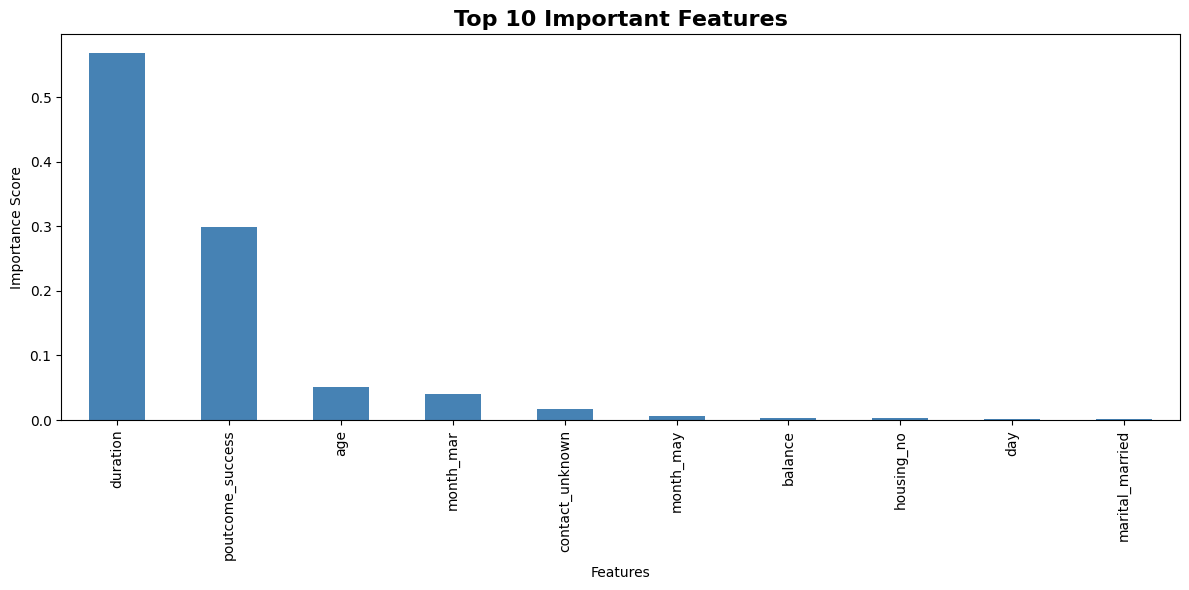

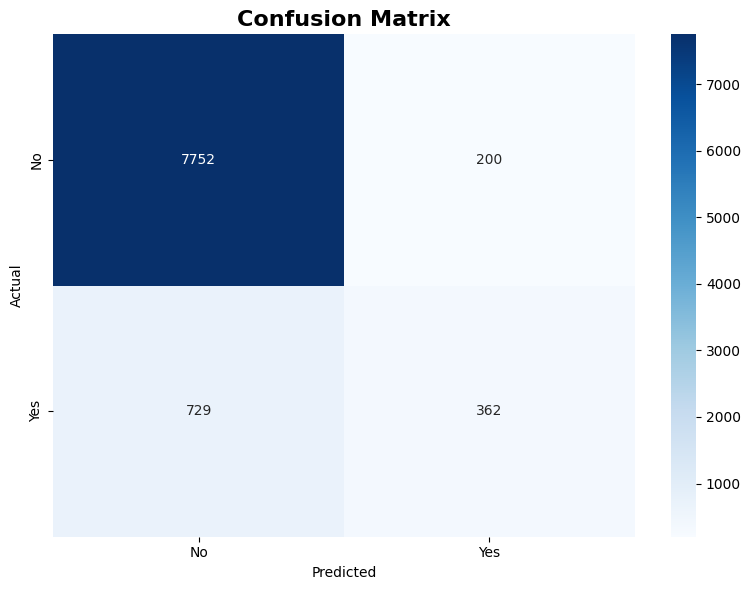

Task 3 Complete! ✅


<Figure size 640x480 with 0 Axes>

In [ ]:
# PRODIGY INFOTECH - TASK 03
# Decision Tree Classifier
# Bank Marketing Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn import tree

# STEP 1 - Load Data
df = pd.read_csv('bank-full.csv', sep=';')
print("Shape:", df.shape)
print(df.head())
print(df['y'].value_counts())

# STEP 2 - Prepare Data
# Convert yes/no to 1/0
df['y'] = df['y'].map({'yes':1, 'no':0})

# Convert categorical columns
df = pd.get_dummies(df, columns=[
    'job','marital','education',
    'default','housing','loan',
    'contact','month','poutcome'])

print("Cleaned shape:", df.shape)

# STEP 3 - Split Data
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = \
train_test_split(X, y,
                 test_size=0.2,
                 random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# STEP 4 - Build Decision Tree
model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42)

model.fit(X_train, y_train)

# STEP 5 - Evaluate Model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# STEP 6 - Feature Importance Chart
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
importance.plot(kind='bar', color='steelblue')
plt.title('Top 10 Important Features',
          fontsize=16, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# STEP 7 - Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])
plt.title('Confusion Matrix',
          fontsize=16, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("Task 3 Complete! ✅")
plt.savefig('task3_plots.png',dpi=300,bbox_inches='tight')